# Strategy Testing
In this notebook various tests are ran on mockups to explain the process behind implementing the strategy. Such functions implemented to aid the strategy are the rolling z-score and signal generator in [`strategy.py`](../src/strategy.py).

## Rolling Z-score
In this function we aim to compute the z-score using a rolling mean and rolling standard deviation. This allows us to account for only knowing information at the previous states and not using look-ahead bias. In order to test this we create a mean-reverting series to act as our test spread, and run the rolling_zscore function on this. We expect that the mean should be close to zero since all the z-scores describe the mean-reversion of the series. Furthermore, we expect a standard deviation of around one and a min or max of around ±2-3.

In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys
from pathlib import Path

project_root = Path.cwd().parent # parent dir
sys.path.insert(0,str(project_root/"src"))
from strategy import rolling_zscore, generate_signals_stateless
from cointegration import engle_granger_test
from data_loader import download_prices

np.random.seed(42)
n = 1000
phi = 0.9
ar = np.zeros(n)
shocks = np.random.normal(0, 1, n)
for i in range(1, n):
    ar[i] = phi * ar[i-1] + shocks[i]
spread = pd.Series(ar)

z = rolling_zscore(spread, window=60)

print(z.describe())



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
count    941.000000
mean       0.067436
std        1.126697
min       -2.901968
25%       -0.721996
50%        0.002709
75%        0.834848
max        2.963693
dtype: float64


Next, we plot the z-score and spread to confirm that the z-score seems to cross ±2 when the spread stretches, and zero when the spread reverts.

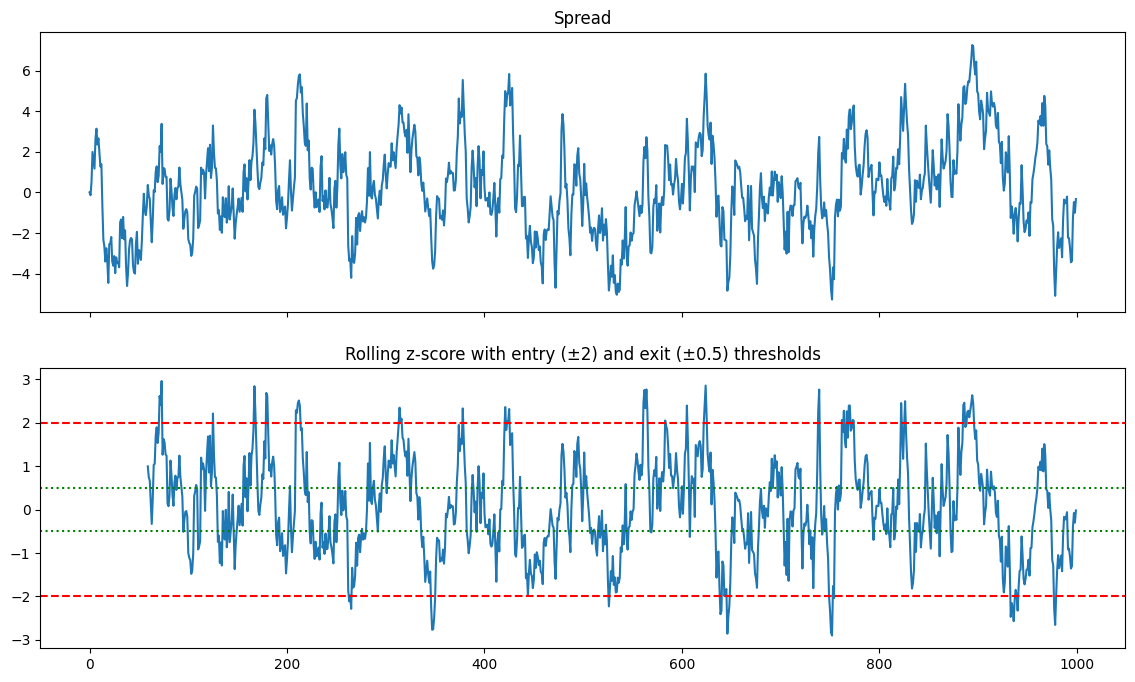

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(spread); ax1.set_title('Spread')
ax2.plot(z); ax2.axhline(2, color='r', ls='--'); ax2.axhline(-2, color='r', ls='--')
ax2.axhline(0.5, color='g', ls=':'); ax2.axhline(-0.5, color='g', ls=':')
ax2.set_title('Rolling z-score with entry (±2) and exit (±0.5) thresholds')
plt.show()

Using the rolling_zscore function along with our stateless signal generator, we can also check the proportions of short entries, long entries, and flat segments. This allows for a basic sanity check where we can eyeball the generator at work. We note that since this generator is stateless, the regions between entry and exit thresholds are considered ambigous. This is because the generator does not hold information regarding if we are holding a short or long position.

In [ ]:
# Load EWA/EWC, get the spread from the hedge ratio
prices = download_prices(['EWA', 'EWC'], '2015-01-01', '2024-12-31')
eg = engle_granger_test(prices['EWA'], prices['EWC'])
spread = eg['residuals']

z = rolling_zscore(spread, window=60)
signals = generate_signals_stateless(z)

# How many entry signals?
print(f"Long-spread entries: {(signals == 1).sum()}")
print(f"Short-spread entries: {(signals == -1).sum()}")
print(f"Flat: {(signals == 0).sum()}")

Long-spread entries: 141
Short-spread entries: 148
Flat: 2226
